### LeNet5 - 얀르쿤 +> CNN/손글씨 우편번호 // Keras => 모델층 구현/ 파라미터 계산
- Input (28*28*1) 
- -> 합성곱(Conv2D - filter : 6, kernel : 5*5, activation : sigmoid, padding : same) 
- -> fooling(Average - size : 2) 
- -> 합성곱(Conv2D - filter : 16, kernel : 5*5, activation : sigmoid, padding : valid) 
- -> fooling(Average - size : 2)
- -> Flatten 
- -> Dense(120, activation : sigmoid) 
- -> Dense(84, activation : sigmoid) 
- -> Dense(10, activation : softmax) 

In [1]:
from tensorflow.keras import datasets

# 데이터 로드 (학습용 6만 개, 테스트용 1만 개)
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

# LeNet-5는 32x32 입력을 사용하므로, 28x28인 MNIST를 패딩하거나 리사이즈해서 사용합니다.

In [11]:
# train_images
train_labels

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [7]:
train_images.shape

(60000, 28, 28)

In [2]:
import tensorflow as tf
import numpy as np
import random

# 모든 시드를 하나로 통일
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

In [8]:
test_scaled = test_images.reshape(-1, 28, 28, 1) / 255.0

In [3]:
train_scaled = train_images.reshape(-1, 28, 28, 1) / 255.0

In [4]:
from sklearn.model_selection import train_test_split
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_labels, test_size=0.2, random_state=42)

In [15]:
train_scaled.shape

(48000, 28, 28, 1)

In [17]:
train_target.shape

(48000,)

In [5]:
import keras
from tensorflow.keras import layers, models
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28,28,1)))
model.add(keras.layers.Conv2D(6, kernel_size=5, activation='sigmoid', padding='same'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Conv2D(16, kernel_size=5, activation='sigmoid', padding='valid'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(120, activation='sigmoid'))
model.add(keras.layers.Dense(84, activation='sigmoid'))
model.add(keras.layers.Dense(10, activation='softmax'))

In [2]:
# from tensorflow.keras import layers, models

# model = models.Sequential([
#     # C1: 합성곱 층 (필터 6개, 5x5)
#     layers.Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(32, 32, 1)),
#     # S2: 평균 풀링 층 (2x2)
#     layers.AveragePooling2D(pool_size=(2, 2)),
#     # C3: 합성곱 층 (필터 16개, 5x5)
#     layers.Conv2D(16, kernel_size=(5, 5), activation='tanh'),
#     # S4: 평균 풀링 층 (2x2)
#     layers.AveragePooling2D(pool_size=(2, 2)),
#     # C5: Fully Connected 역할을 하는 합성곱 층 (필터 120개, 5x5)
#     layers.Flatten(),
#     layers.Dense(120, activation='tanh'),
#     # F6: Fully Connected 층 (84개 유닛)
#     layers.Dense(84, activation='tanh'),
#     # Output: 10개 클래스 (0~9)
#     layers.Dense(10, activation='softmax')
# ])

In [5]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 6)         156       
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 6)         0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 10, 10, 16)        2416      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 16)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 400)               0         
                                                                 
 dense (Dense)               (None, 120)               4

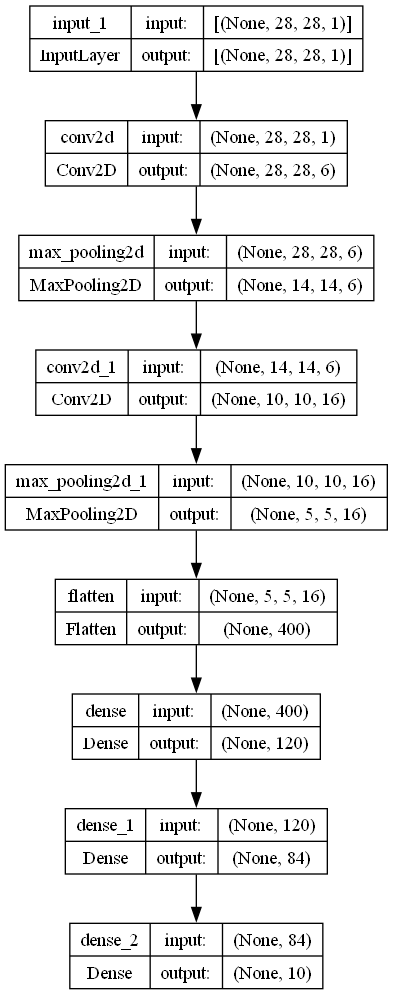

In [6]:
import keras
keras.utils.plot_model(model, show_shapes=True)

In [6]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('LeNet5-cnn-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20, 
                    validation_data=(val_scaled, val_target),
                   callbacks=[checkpoint_cb, early_stopping_cb])


Epoch 1/20


1500/1500 [==============================] - 5s 3ms/step - loss: 0.8146 - accuracy: 0.7331 - val_loss: 0.1928 - val_accuracy: 0.9440
Epoch 2/20
1500/1500 [==============================] - 4s 3ms/step - loss: 0.1430 - accuracy: 0.9584 - val_loss: 0.1151 - val_accuracy: 0.9648
Epoch 3/20
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0906 - accuracy: 0.9724 - val_loss: 0.0738 - val_accuracy: 0.9778
Epoch 4/20
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0690 - accuracy: 0.9794 - val_loss: 0.0656 - val_accuracy: 0.9793
Epoch 5/20
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0571 - accuracy: 0.9820 - val_loss: 0.0645 - val_accuracy: 0.9804
Epoch 6/20
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0489 - accuracy: 0.9848 - val_loss: 0.0464 - val_accuracy: 0.9862
Epoch 7/20
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0412 - accuracy: 0.9871 - val_loss: 0.0452 - val_accura

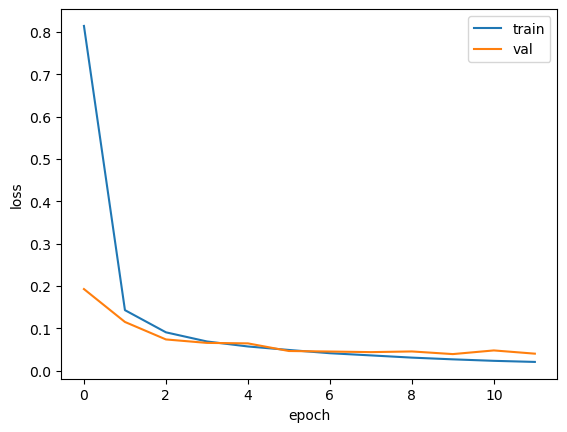

In [7]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [10]:
# 한 번도 보지 못한 진짜 시험 문제로 채점하기
test_loss, test_acc = model.evaluate(test_scaled, test_labels)
print(f"최종 테스트 정확도: {test_acc}")

313/313 [==============================] - 0s 1ms/step - loss: 0.0368 - accuracy: 0.9886
최종 테스트 정확도: 0.9886000156402588


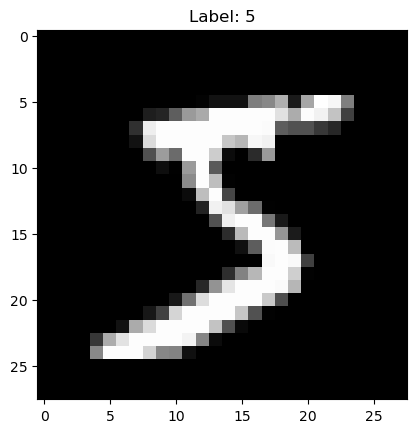

In [20]:
import matplotlib.pyplot as plt
from tensorflow.keras import datasets

# 데이터 로드
(train_images, train_labels), _ = datasets.mnist.load_data()

# 첫 번째 데이터를 이미지로 보기
plt.imshow(train_images[0], cmap='gray')
plt.title(f"Label: {train_labels[0]}")
plt.show()

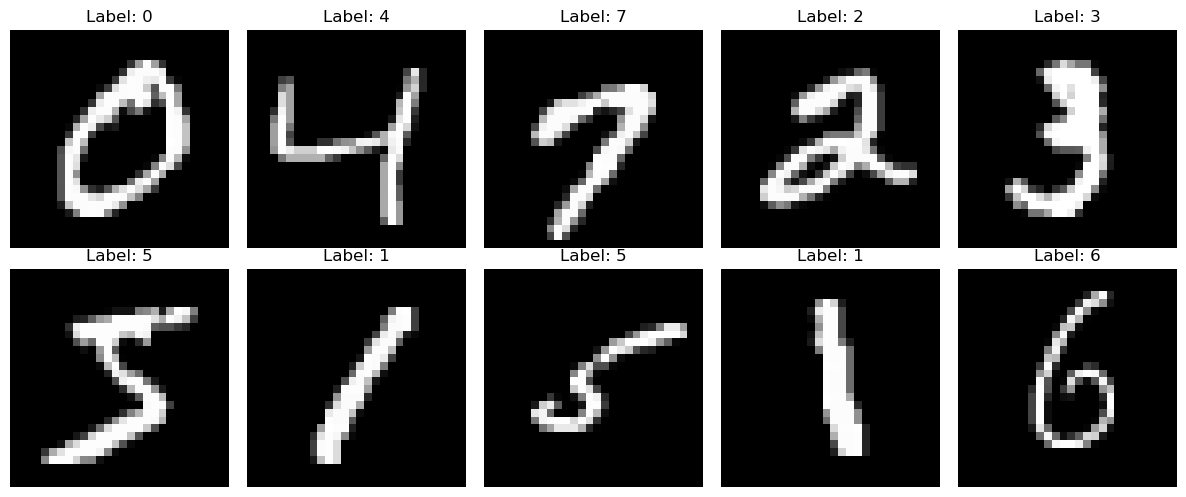

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import datasets

# 1. 데이터 로드
(train_images, train_labels), _ = datasets.mnist.load_data()

# 2. 각 숫자(0~9)가 처음 나타나는 인덱스 찾기
# return_index=True를 하면 해당 값이 처음 등장하는 위치를 반환합니다.
unique_labels, unique_indices = np.unique(train_target, return_index=True)

# 3. 시각화 (2행 5열로 배치)
plt.figure(figsize=(12, 5))

for i, idx in enumerate(unique_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[idx], cmap='gray')
    plt.title(f"Label: {train_labels[idx]}")
    plt.axis('off') # 격자 테두리 숨기기

plt.tight_layout()
plt.show()

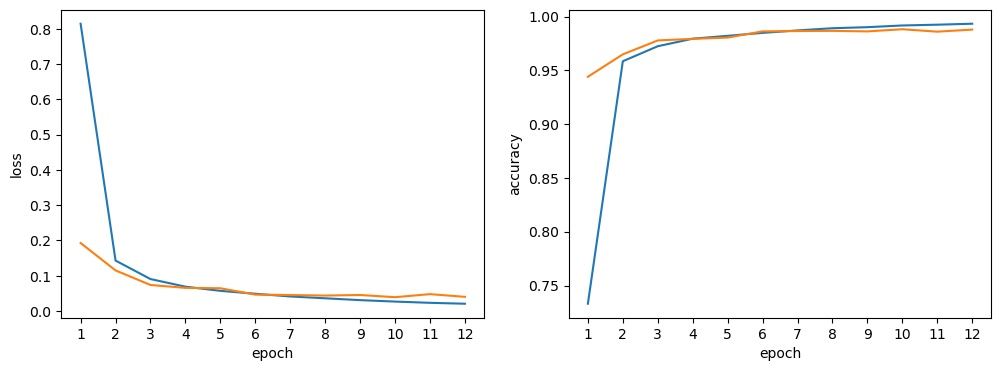

In [13]:
epoches = range(1, len(history.history['loss'])+1)

fig, axs = plt.subplots(1,2, figsize=(12,4))
axs[0].plot(epoches, history.history['loss'])
axs[0].plot(epoches, history.history['val_loss'])
axs[0].set_xticks(epoches)
axs[0].set_xlabel('epoch')
axs[0].set_ylabel('loss')
axs[1].plot(epoches, history.history['accuracy'])
axs[1].plot(epoches, history.history['val_accuracy'])
axs[1].set_xticks(epoches)
axs[1].set_xlabel('epoch')
axs[1].set_ylabel('accuracy')
plt.show()